In [1]:
from utils.binaries import *
from utils.plotting import *

10:38:14 (  +60.6s) [INFO   ] -- import logging
10:38:14 (  +152ms) [INFO   ] -- import numpy as np
10:38:14 (   +12ms) [INFO   ] -- import uncertainties
10:38:15 (  +410ms) [INFO   ] -- import pandas as pd
10:38:15 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
10:38:15 (    +3ms) [INFO   ] -- import binaries.tools as tools
10:38:15 (    +2ms) [INFO   ] -- set MONI_PATH = PosixPath('/cr/work/filip/monit_and_sd')
10:38:15 (    +0ms) [INFO   ] -- set HIST_PATH = PosixPath('/cr/work/filip/monit_and_sd')
10:38:15 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/cr/data01/filip/plots')
10:38:15 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/cr/data01/filip/Data')
10:38:15 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/cr/data01/filip/xy-calibration')
10:38:15 (    +1ms) [INFO   ] -- set OFLN_PATH = PosixPath('/cr/data01/filip/offline/install')
10:38:15 (  +492ms) [INFO   ] -- import matplotlib.pyplot as plt
10:38:16 (  +821ms) [INFO   ] -- import seaborn a

In [2]:
path = "/cr/tempdata01/filip/json_data/icrc2025-test7/"
df_proton = tools.pickle_load(f"{path}/proton.pkl")
df_photon = tools.pickle_load(f"{path}/photon.pkl")

set_plt_style("double")

10:38:16 (  +334ms) [DEBUG  ] -- font size set to 9.5
10:38:16 (    +1ms) [DEBUG  ] -- label size set to 13.0
10:38:16 (    +1ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
10:38:16 (    +1ms) [DEBUG  ] -- markersize set to 2.0
10:38:16 (    +1ms) [DEBUG  ] -- usetex set to False
10:38:16 (    +1ms) [DEBUG  ] -- label size set to 13.0
10:38:16 (    +1ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
10:38:16 (    +1ms) [DEBUG  ] -- markersize set to 2.0
10:38:16 (    +1ms) [DEBUG  ] -- usetex set to False


/tmp/ipykernel_3595122/2179240663.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', title=f"{name} primaries")


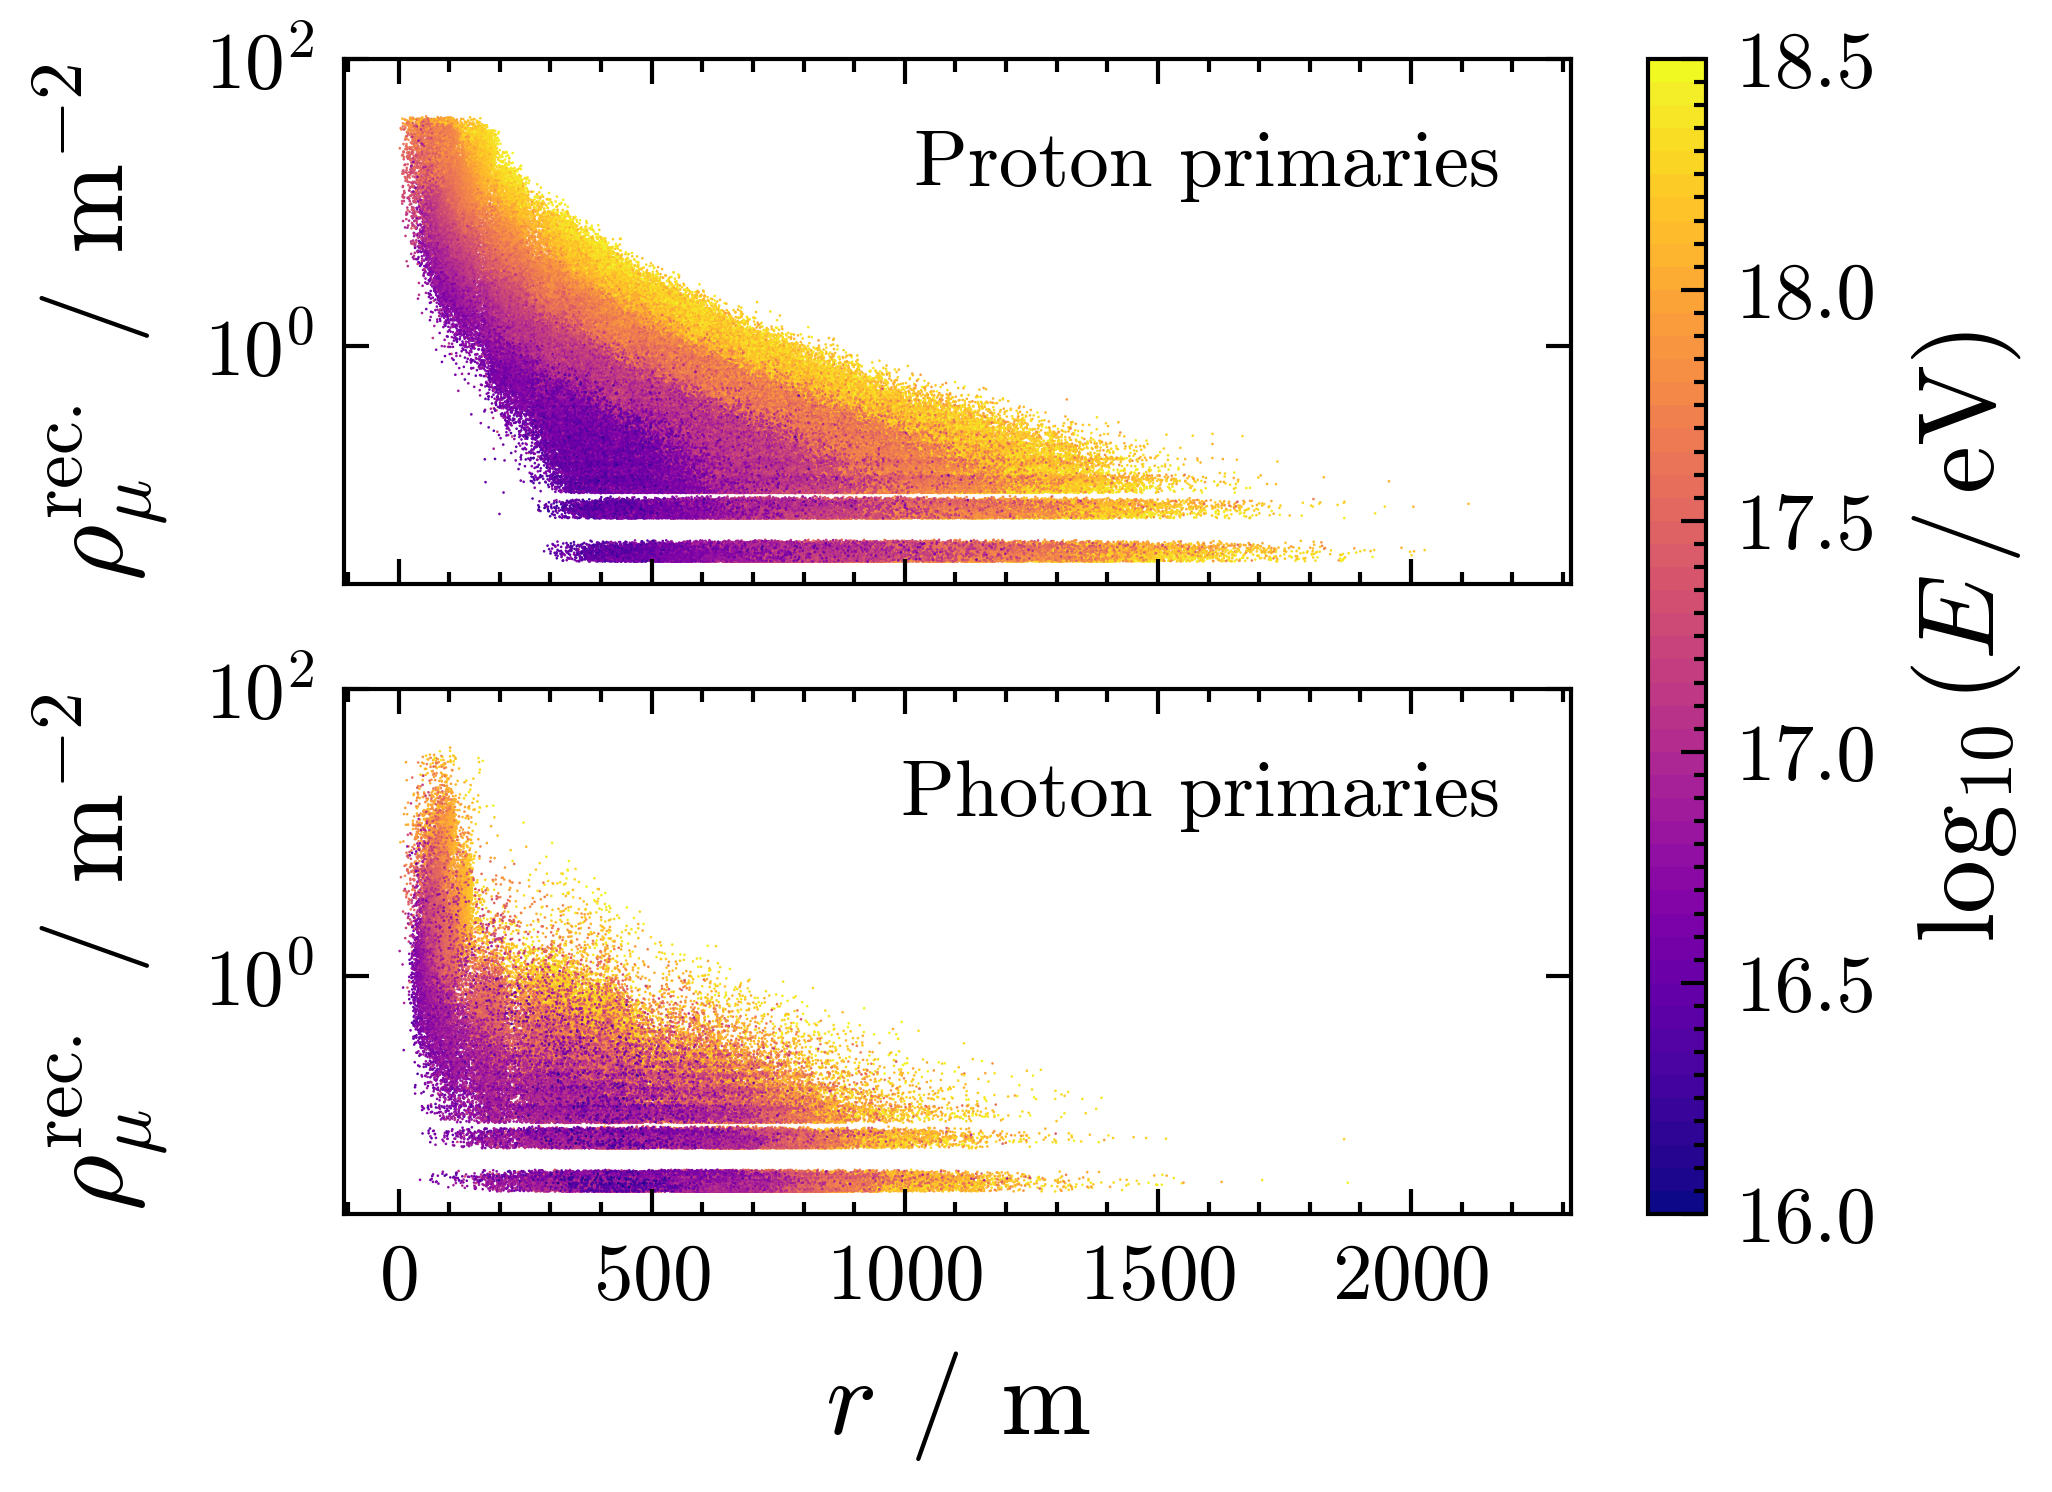

In [3]:
fig, axes = plt.subplots(2, 1, sharex=True, sharey=True)

for primary, ax, name in zip([df_proton, df_photon], axes, ["Proton", "Photon"]):

    lgE = np.log10(primary["shower_size"])
    lin_scale = (lgE - lgE.min()) / (lgE.max() - lgE.min()) 
    colors = plt.cm.plasma(lin_scale.values)

    test = ax.scatter(primary["spd"], primary["muon_density"], s=0.1, ec='none', fc=colors)
    ax.set_ylabel(r"$\rho^\mathrm{rec.}_\mu$ / $\mathrm{m}^{-2}$")
    ax.legend(loc='upper right', title=f"{name} primaries")

ax.set_yscale("log")
ax.set_xlabel("$r$ / m")
ax.set_ylim(None, 1e2)

cbar = plot.add_colorbar(np.arange(16, 18.51, 0.05), 
                         plt.cm.plasma, ax=axes,
                         label="$\log_{10}(E\,/\,\mathrm{eV})$")
cbar.set_ticks(np.linspace(16, 18.5, 6))
cbar.set_ticklabels(np.linspace(16, 18.5, 6))

plot.save(plt.gcf(), "muon_ldf")
